# Notebook 04 — Analyse comparative

Charge les CSV produits par les NB 01, 02, 03, et 03b. Génère :
1. Courbes d'apprentissage superposées
2. Tableau comparatif des performances finales
3. Figures finales prêtes pour le rapport

## Configurations comparées

| # | Configuration | Source |
|---|---|---|
| 1 | PPO-MLP / CartPole-v1 (MDP) | NB 01 |
| 2 | PPO-MLP / CartPole-MaskedVelocity (POMDP) | NB 02 |
| 3 | PPO-MLP + FrameStack / CartPole-MaskedVelocity | NB 03 |
| 4 | PPO-LSTM / CartPole-MaskedVelocity | NB 03b (échec documenté) |

In [10]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
CSV_DIR = ROOT / "results" / "csv"
FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"CSV dir : {CSV_DIR}")
print(f"Fig dir : {FIG_DIR}")

CSV dir : c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv
Fig dir : c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures


## Chargement des résultats

In [11]:
csv_files = sorted(CSV_DIR.glob("*.csv"))
print(f"Trouvé {len(csv_files)} fichier(s) CSV :")
for f in csv_files:
    print(f"  - {f.name}")

dfs = {}
for f in csv_files:
    df = pd.read_csv(f)
    if "config" in df.columns:
        config = df["config"].iloc[0]
    else:
        config = f.stem
    dfs[config] = df
    print(f"\n{config}")
    print(f"  Épisodes : {len(df)}")
    print(f"  Retour final moyen (50 derniers) : {df['return'].tail(50).mean():.2f}")

Trouvé 4 fichier(s) CSV :
  - ppo_lstm_cartpole_masked__seed1.csv
  - ppo_mlp_cartpole_full__seed1.csv
  - ppo_mlp_cartpole_masked__seed1.csv
  - ppo_mlp_framestack_masked__seed1.csv

PPO-LSTM / CartPole-Masked (POMDP)
  Épisodes : 12933
  Retour final moyen (50 derniers) : 20.58

PPO-MLP / CartPole (MDP)
  Épisodes : 1033
  Retour final moyen (50 derniers) : 487.54

PPO-MLP / CartPole-Masked (POMDP)
  Épisodes : 6275
  Retour final moyen (50 derniers) : 54.04

PPO-MLP+FrameStack / CartPole-Masked (POMDP)
  Épisodes : 2697
  Retour final moyen (50 derniers) : 345.90


## Courbes superposées (figure principale du rapport)

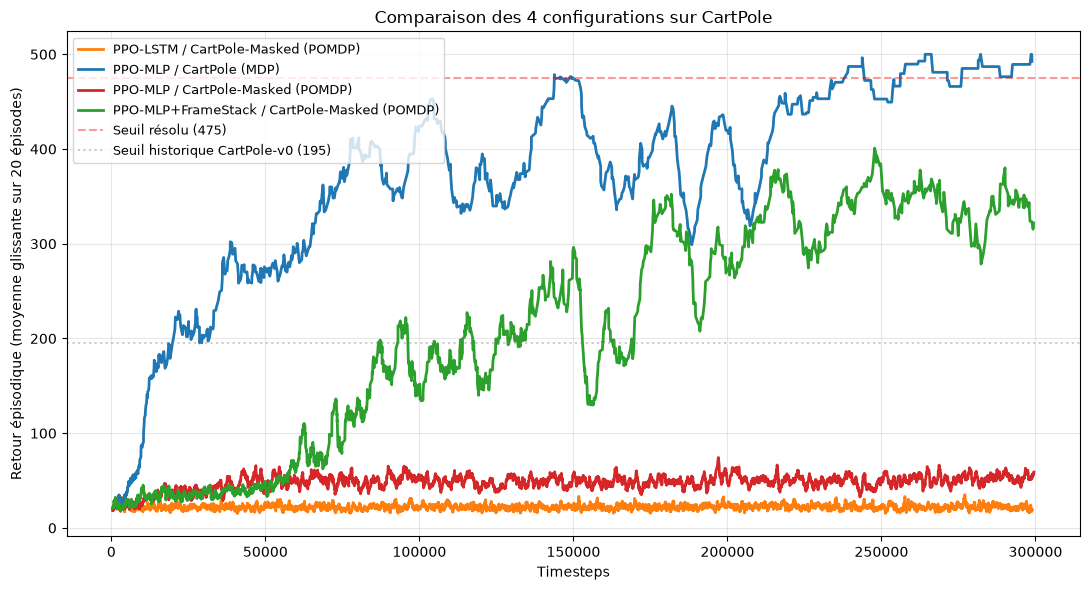


Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\comparison_curves.png


In [12]:
fig, ax = plt.subplots(1, 1, figsize=(11, 6))

# Mapping config → couleur (cohérent à travers tous les graphiques)
colors = {
    "PPO-MLP / CartPole (MDP)": "C0",
    "PPO-MLP / CartPole-Masked (POMDP)": "C3",  # rouge : échec
    "PPO-MLP+FrameStack / CartPole-Masked (POMDP)": "C2",  # vert : succès
    "PPO-LSTM / CartPole-Masked (POMDP)": "C1",  # orange : instable
}

for config, df in dfs.items():
    steps = df["step"].values
    returns = df["return"].values
    color = colors.get(config, "gray")
    if len(returns) >= 20:
        smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
        ax.plot(steps[19:], smooth, label=config, linewidth=2, color=color)
    else:
        ax.plot(steps, returns, label=config, linewidth=2, color=color)

ax.axhline(475, color="red", linestyle="--", alpha=0.4, label="Seuil résolu (475)")
ax.axhline(195, color="gray", linestyle=":", alpha=0.4, label="Seuil historique CartPole-v0 (195)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique (moyenne glissante sur 20 épisodes)")
ax.set_title("Comparaison des 4 configurations sur CartPole")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "comparison_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure → {fig_path}")

## Tableau comparatif

In [13]:
rows = []
for config, df in dfs.items():
    returns = df["return"].values
    n_last = min(50, len(returns))
    rows.append({
        "Configuration": config,
        "Épisodes totaux": len(returns),
        "Retour final (moy 50)": f"{np.mean(returns[-n_last:]):.2f}",
        "Retour final (std 50)": f"{np.std(returns[-n_last:]):.2f}",
        "Retour max": f"{np.max(returns):.0f}",
        "Timesteps": int(df["step"].max()),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

summary_path = FIG_DIR / "summary_table.csv"
summary.to_csv(summary_path, index=False)
print(f"\nTableau → {summary_path}")

                               Configuration  Épisodes totaux Retour final (moy 50) Retour final (std 50) Retour max  Timesteps
          PPO-LSTM / CartPole-Masked (POMDP)            12933                 20.58                 10.52        135     298992
                    PPO-MLP / CartPole (MDP)             1033                487.54                 50.48        500     298868
           PPO-MLP / CartPole-Masked (POMDP)             6275                 54.04                 19.75        182     299512
PPO-MLP+FrameStack / CartPole-Masked (POMDP)             2697                345.90                117.48        500     299384

Tableau → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\summary_table.csv


## Figure secondaire — Focus sur le POMDP

Cette figure compare uniquement les configurations qui jouent sur le POMDP (MLP simple vs MLP+FrameStack vs LSTM). C'est la figure qui répond le plus directement à la question de recherche.

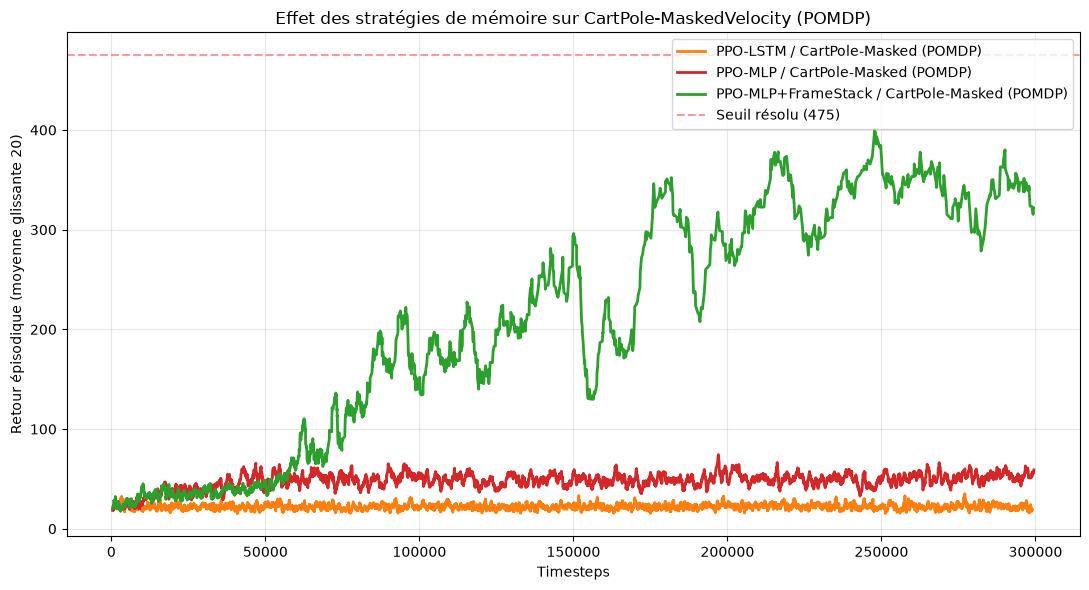

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\pomdp_strategies.png


In [14]:
fig, ax = plt.subplots(1, 1, figsize=(11, 6))
pomdp_configs = [k for k in dfs.keys() if "Masked" in k or "POMDP" in k]
for config in pomdp_configs:
    df = dfs[config]
    steps = df["step"].values
    returns = df["return"].values
    color = colors.get(config, "gray")
    if len(returns) >= 20:
        smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
        ax.plot(steps[19:], smooth, label=config, linewidth=2, color=color)

ax.axhline(475, color="red", linestyle="--", alpha=0.4, label="Seuil résolu (475)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique (moyenne glissante 20)")
ax.set_title("Effet des stratégies de mémoire sur CartPole-MaskedVelocity (POMDP)")
ax.legend(loc="best", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "pomdp_strategies.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure → {fig_path}")

## Bullet points clés pour le rapport

Sur la base des courbes et du tableau, voici ce que tu peux affirmer :

1. **PPO-MLP atteint la performance optimale sur le MDP complet** → l'implémentation est validée.
2. **PPO-MLP s'effondre sur le POMDP** → l'observabilité partielle pose un vrai problème.
3. **Frame Stacking récupère une grande partie de la performance** avec un mécanisme simple (concaténer les `k` dernières observations).
4. **PPO-LSTM n'a pas convergé dans le budget de timesteps**, cohérent avec les observations d'instabilité de Ni et al. (2022).
5. **Leçon méthodologique** : commencer par la baseline simple (FrameStack) avant de passer aux méthodes complexes (LSTM).